# BTC Liquidation — Model Comparison

So sánh các thuật toán Gradient Boosting và Ensemble tương tự XGBoost:

| Model | Thư viện | Đặc điểm |
|---|---|---|
| **XGBoost** | xgboost | Baseline hiện tại |
| **LightGBM** | lightgbm | Leaf-wise growth, nhanh hơn XGB |
| **CatBoost** | catboost | Ordered boosting, tốt với categorical |
| **HistGradientBoosting** | sklearn | Sklearn version của LightGBM idea |
| **Random Forest** | sklearn | Bagging ensemble, ít overfit |
| **Extra Trees** | sklearn | RF + random splits, nhanh nhất |
| **GradientBoosting** | sklearn | Boosting gốc, chậm hơn XGB |
| **Logistic Regression** | sklearn | Linear baseline để so sánh |

**Metrics đánh giá:** AUC-ROC, Precision/Recall/F1 @ threshold 0.65, Brier Score, training time  
**Data:** `features_5m.csv` — time-series split (không shuffle để tránh data leakage)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    brier_score_loss, average_precision_score,
    precision_recall_curve, confusion_matrix,
)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression

# Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#21262d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'grid.color':       '#21262d',
    'text.color':       '#c9d1d9',
    'font.size':        10,
})

GREEN  = '#3fb950'
RED    = '#f85149'
BLUE   = '#58a6ff'
YELLOW = '#e3b341'
PURPLE = '#bc8cff'
MUTED  = '#8b949e'

ROOT = Path('..').resolve()
FEATURES_FILE = ROOT / 'data' / 'features_5m.csv'
THRESHOLD     = 0.65

print('✓ Imports OK')
print(f'  Features file: {FEATURES_FILE}')
print(f'  Signal threshold: {THRESHOLD}')

✓ Imports OK
  Features file: /home/coder/data/features_5m.csv
  Signal threshold: 0.65


## 1. Load & Prepare Data

In [2]:
FEATURE_COLS = [
    # Price
    'price_change_5m', 'price_change_1m', 'volatility_5m',
    'volume_5m', 'taker_buy_ratio',
    # Liquidation
    'liq_long_usd_5m', 'liq_short_usd_5m', 'liq_total_5m', 'liq_ratio_5m',
    'dist_to_upper', 'dist_to_lower',
    # Order Book
    'imbalance_now', 'imbalance_avg_1m', 'imbalance_trend',
    'spread_now', 'bid_vol_now', 'ask_vol_now', 'wall_ratio',
    # CVD + Whale
    'cvd_delta_5m', 'cvd_delta_1m',
    'whale_buy_count', 'whale_sell_count', 'whale_net',
    'whale_buy_usd_5m', 'whale_sell_usd_5m', 'whale_dominance',
    # OI
    'delta_oi_5m', 'delta_oi_30m', 'delta_oi_1h', 'oi_acceleration',
    # Funding
    'funding_rate', 'funding_rate_abs', 'funding_bias',
    'funding_long_heavy', 'funding_short_heavy',
    'funding_rate_change', 'funding_trend_3h',
    'secs_to_next_funding', 'funding_urgency',
]

def load_data(path: Path):
    df = pd.read_csv(path)
    df['label'] = pd.to_numeric(df['label'], errors='coerce')
    df = df[df['label'].isin([0, 1])].copy()
    df['label'] = df['label'].astype(int)
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
    df = df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

    # Boolean cols → int
    for col in ('funding_long_heavy', 'funding_short_heavy'):
        if col in df.columns:
            df[col] = df[col].astype(str).map(
                {'True': 1, 'False': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0}
            ).astype(float)

    avail = [c for c in FEATURE_COLS if c in df.columns]
    X = df[avail].apply(pd.to_numeric, errors='coerce')
    y = df['label'].values
    return X, y, df, avail

X, y, df_full, features = load_data(FEATURES_FILE)

# Time-based split: 80% train / 20% test
n       = len(X)
n_train = int(n * 0.80)
X_train, X_test = X.iloc[:n_train], X.iloc[n_train:]
y_train, y_test = y[:n_train],      y[n_train:]

# Impute
imputer  = SimpleImputer(strategy='median')
X_tr_imp = imputer.fit_transform(X_train)
X_te_imp = imputer.transform(X_test)

# scale_pos_weight
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
spw   = n_neg / n_pos if n_pos > 0 else 1.0

print(f'Tổng rows    : {n}')
print(f'Train / Test : {n_train} / {n - n_train}')
print(f'label=1 (train): {n_pos} ({n_pos/n_train*100:.1f}%)')
print(f'label=0 (train): {n_neg} ({n_neg/n_train*100:.1f}%)')
print(f'scale_pos_weight: {spw:.2f}')
print(f'Features used: {len(features)}')

Tổng rows    : 960
Train / Test : 768 / 192
label=1 (train): 284 (37.0%)
label=0 (train): 484 (63.0%)
scale_pos_weight: 1.70
Features used: 39


## 2. Định nghĩa Models

In [3]:
MODELS = {
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric='auc', random_state=42, verbosity=0,
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw,
        random_state=42, verbose=-1,
    ),
    'CatBoost': CatBoostClassifier(
        iterations=300, depth=6, learning_rate=0.05,
        scale_pos_weight=spw,
        random_seed=42, verbose=0,
    ),
    'HistGradBoost': HistGradientBoostingClassifier(
        max_iter=300, max_depth=6, learning_rate=0.05,
        random_state=42,
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=8,
        class_weight='balanced',
        random_state=42, n_jobs=-1,
    ),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=300, max_depth=8,
        class_weight='balanced',
        random_state=42, n_jobs=-1,
    ),
    'GradBoost (sklearn)': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=42,
    ),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced', max_iter=1000,
            C=0.1, random_state=42,
        ))
    ]),
}

print(f'Số models: {len(MODELS)}')
for name in MODELS:
    print(f'  · {name}')

Số models: 8
  · XGBoost
  · LightGBM
  · CatBoost
  · HistGradBoost
  · RandomForest
  · ExtraTrees
  · GradBoost (sklearn)
  · Logistic Regression


## 3. Train & Evaluate tất cả Models

In [4]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, threshold=THRESHOLD):
    t0 = time.perf_counter()

    if name == 'XGBoost':
        # Early stopping với 15% validation set bên trong train
        n_val = int(len(X_tr) * 0.15)
        model.fit(
            X_tr[:-n_val], y_tr[:-n_val],
            eval_set=[(X_tr[-n_val:], y_tr[-n_val:])],
            verbose=False,
        )
    elif name == 'LightGBM':
        n_val = int(len(X_tr) * 0.15)
        model.fit(
            X_tr[:-n_val], y_tr[:-n_val],
            eval_set=[(X_tr[-n_val:], y_tr[-n_val:])],
            callbacks=[
                __import__('lightgbm').early_stopping(30, verbose=False),
                __import__('lightgbm').log_evaluation(-1),
            ],
        )
    else:
        model.fit(X_tr, y_tr)

    train_time = time.perf_counter() - t0

    # Probabilities
    prob_tr = model.predict_proba(X_tr)[:, 1]
    prob_te = model.predict_proba(X_te)[:, 1]

    # AUC
    auc_tr = roc_auc_score(y_tr, prob_tr) if len(set(y_tr)) > 1 else float('nan')
    auc_te = roc_auc_score(y_te, prob_te) if len(set(y_te)) > 1 else float('nan')

    # PR-AUC (Average Precision)
    pr_auc = average_precision_score(y_te, prob_te) if len(set(y_te)) > 1 else float('nan')

    # @ threshold
    pred_te = (prob_te >= threshold).astype(int)
    n_sig   = pred_te.sum()
    prec    = precision_score(y_te, pred_te, zero_division=0)
    rec     = recall_score(y_te, pred_te, zero_division=0)
    f1      = f1_score(y_te, pred_te, zero_division=0)

    # Brier score (calibration)
    brier = brier_score_loss(y_te, prob_te)

    # Overfit gap
    gap = auc_tr - auc_te

    return {
        'name':       name,
        'model':      model,
        'prob_tr':    prob_tr,
        'prob_te':    prob_te,
        'auc_train':  round(auc_tr, 4),
        'auc_test':   round(auc_te, 4),
        'pr_auc':     round(pr_auc, 4),
        'overfit_gap': round(gap, 4),
        'precision':  round(prec, 4),
        'recall':     round(rec, 4),
        'f1':         round(f1, 4),
        'brier':      round(brier, 4),
        'n_signals':  int(n_sig),
        'train_sec':  round(train_time, 2),
    }


results = {}
for name, model in MODELS.items():
    print(f'Training {name:<22}', end=' ... ')
    r = evaluate(name, model, X_tr_imp, y_train, X_te_imp, y_test)
    results[name] = r
    flag = '⚠️ overfit' if r['overfit_gap'] > 0.10 else ''
    print(f"AUC={r['auc_test']:.4f}  Prec={r['precision']:.2f}  F1={r['f1']:.2f}  {r['train_sec']:.1f}s  {flag}")

print('\n✓ Done')

Training XGBoost                ... 

AUC=0.5909  Prec=0.62  F1=0.28  13.3s  ⚠️ overfit
Training LightGBM               ... 

AUC=0.6348  Prec=0.00  F1=0.00  1.1s  ⚠️ overfit
Training CatBoost               ... 

AUC=0.6078  Prec=0.56  F1=0.10  1.0s  ⚠️ overfit
Training HistGradBoost          ... 

AUC=0.5795  Prec=0.56  F1=0.26  156.5s  ⚠️ overfit
Training RandomForest           ... 

AUC=0.5782  Prec=0.00  F1=0.00  0.8s  ⚠️ overfit
Training ExtraTrees             ... 

AUC=0.5582  Prec=0.00  F1=0.00  0.6s  ⚠️ overfit
Training GradBoost (sklearn)    ... 

AUC=0.5619  Prec=0.54  F1=0.23  1.6s  ⚠️ overfit
Training Logistic Regression    ... AUC=0.5165  Prec=0.46  F1=0.36  0.0s  ⚠️ overfit

✓ Done


## 4. Bảng tổng hợp kết quả

In [5]:
summary = pd.DataFrame([
    {
        'Model':         r['name'],
        'AUC Train':     r['auc_train'],
        'AUC Test':      r['auc_test'],
        'PR-AUC':        r['pr_auc'],
        'Overfit Gap':   r['overfit_gap'],
        f'Precision@{THRESHOLD}': r['precision'],
        f'Recall@{THRESHOLD}':    r['recall'],
        f'F1@{THRESHOLD}':        r['f1'],
        'Brier ↓':       r['brier'],
        'Signals':       r['n_signals'],
        'Train(s)':      r['train_sec'],
    }
    for r in results.values()
])

summary = summary.sort_values('AUC Test', ascending=False).reset_index(drop=True)

def color_auc(v):  return f'color: {GREEN}' if v >= 0.70 else (f'color: {YELLOW}' if v >= 0.60 else f'color: {RED}')
def color_gap(v):  return f'color: {RED}' if v > 0.10 else ''
def color_brier(v): return f'color: {GREEN}' if v < 0.2 else (f'color: {YELLOW}' if v < 0.25 else f'color: {RED}')

(
    summary.style
    .format({
        'AUC Train': '{:.4f}', 'AUC Test': '{:.4f}', 'PR-AUC': '{:.4f}',
        'Overfit Gap': '{:+.4f}',
        f'Precision@{THRESHOLD}': '{:.3f}',
        f'Recall@{THRESHOLD}': '{:.3f}',
        f'F1@{THRESHOLD}': '{:.3f}',
        'Brier ↓': '{:.4f}', 'Train(s)': '{:.1f}',
    })
    .applymap(color_auc, subset=['AUC Test'])
    .applymap(color_gap, subset=['Overfit Gap'])
    .applymap(color_brier, subset=['Brier ↓'])
    .set_caption(f'Model Comparison — threshold={THRESHOLD}')
)

,Model,AUC Train,AUC Test,PR-AUC,Overfit Gap,Precision@0.65,Recall@0.65,F1@0.65,Brier ↓,Signals,Train(s)
0,LightGBM,0.9126,0.6348,0.6039,+0.2779,0.000,0.000,0.000,0.2357,0,1.1
1,CatBoost,1.0000,0.6078,0.5562,+0.3922,0.556,0.056,0.102,0.2534,9,1.0
2,XGBoost,0.9842,0.5909,0.5341,+0.3933,0.615,0.180,0.278,0.2760,26,13.3
3,HistGradBoost,1.0000,0.5795,0.5262,+0.4205,0.556,0.169,0.259,0.2820,27,156.5
4,RandomForest,1.0000,0.5782,0.5183,+0.4218,0.000,0.000,0.000,0.2427,0,0.8
5,GradBoost (sklearn),1.0000,0.5619,0.5203,+0.4381,0.542,0.146,0.230,0.2638,24,1.6
6,ExtraTrees,0.9990,0.5582,0.5118,+0.4408,0.000,0.000,0.000,0.2463,0,0.6
7,Logistic Regression,0.6794,0.5165,0.4687,+0.1629,0.458,0.303,0.365,0.2716,59,0.0


## 5. ROC Curve — tất cả models

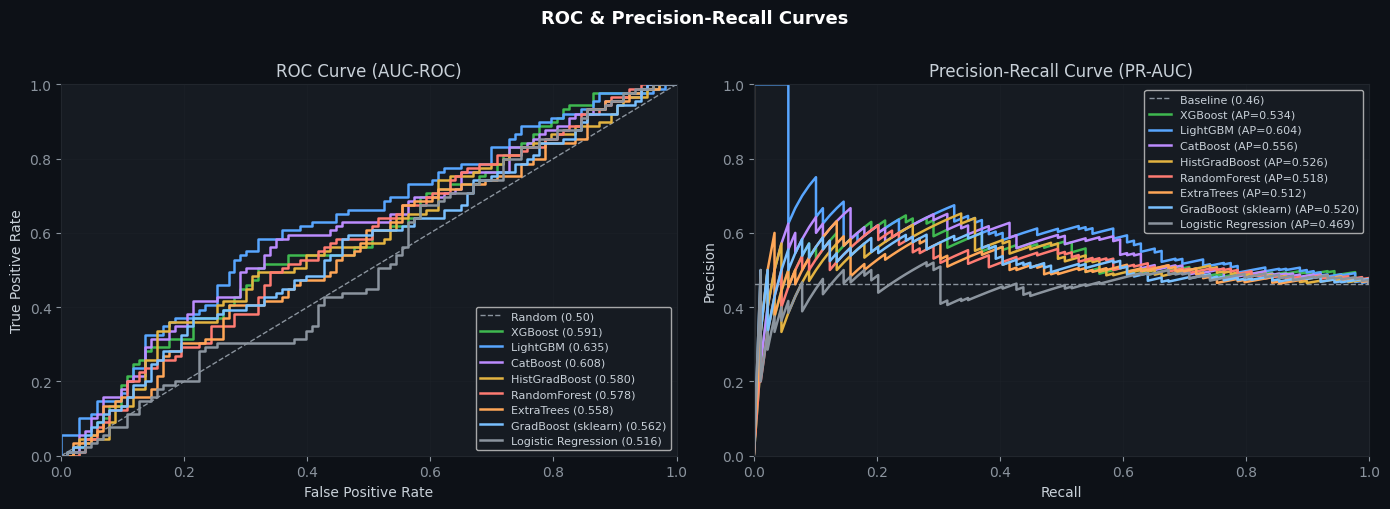

In [6]:
COLORS = [GREEN, BLUE, PURPLE, YELLOW, '#ff7b72', '#ffa657', '#79c0ff', MUTED]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROC & Precision-Recall Curves', fontsize=13, fontweight='bold', color='white', y=1.01)

# ROC
ax = axes[0]
ax.plot([0,1],[0,1], '--', color=MUTED, lw=1, label='Random (0.50)')
for (name, r), col in zip(results.items(), COLORS):
    fpr, tpr, _ = roc_curve(y_test, r['prob_te'])
    ax.plot(fpr, tpr, color=col, lw=1.8, label=f"{name} ({r['auc_test']:.3f})")
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (AUC-ROC)')
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0,1); ax.set_ylim(0,1)

# Precision-Recall
ax = axes[1]
baseline_pr = y_test.mean()
ax.axhline(baseline_pr, ls='--', color=MUTED, lw=1, label=f'Baseline ({baseline_pr:.2f})')
for (name, r), col in zip(results.items(), COLORS):
    prec_c, rec_c, _ = precision_recall_curve(y_test, r['prob_te'])
    ax.plot(rec_c, prec_c, color=col, lw=1.8, label=f"{name} (AP={r['pr_auc']:.3f})")
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve (PR-AUC)')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=130, bbox_inches='tight')
plt.show()

## 6. AUC Test vs Overfit Gap vs Training Time

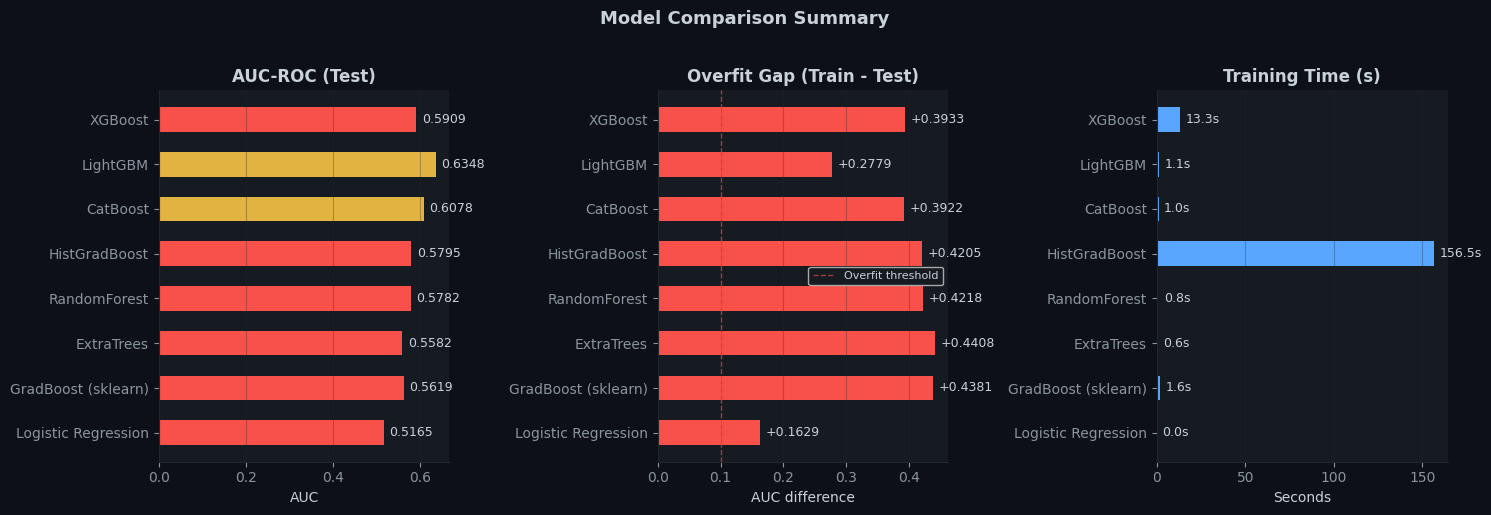

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
names   = [r['name'] for r in results.values()]
auc_te  = [r['auc_test'] for r in results.values()]
gaps    = [r['overfit_gap'] for r in results.values()]
times   = [r['train_sec'] for r in results.values()]
f1s     = [r['f1'] for r in results.values()]

bar_colors_auc  = [GREEN if a >= 0.70 else (YELLOW if a >= 0.60 else RED) for a in auc_te]
bar_colors_gap  = [RED if g > 0.10 else GREEN for g in gaps]
bar_colors_time = [BLUE] * len(times)

for ax, vals, title, ylabel, cols, fmt in zip(
    axes,
    [auc_te, gaps, times],
    ['AUC-ROC (Test)', 'Overfit Gap (Train - Test)', 'Training Time (s)'],
    ['AUC', 'AUC difference', 'Seconds'],
    [bar_colors_auc, bar_colors_gap, bar_colors_time],
    ['{:.4f}', '{:+.4f}', '{:.1f}s'],
):
    bars = ax.barh(names, vals, color=cols, edgecolor='none', height=0.55)
    for bar, v in zip(bars, vals):
        ax.text(max(vals)*0.02 + bar.get_width(), bar.get_y() + bar.get_height()/2,
                fmt.format(v), va='center', fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(ylabel)
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if 'Gap' in title:
        ax.axvline(0.10, color=RED, ls='--', lw=1, alpha=0.6, label='Overfit threshold')
        ax.legend(fontsize=8)

plt.suptitle('Model Comparison Summary', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_summary.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Calibration Curves — Xác suất có đáng tin không?

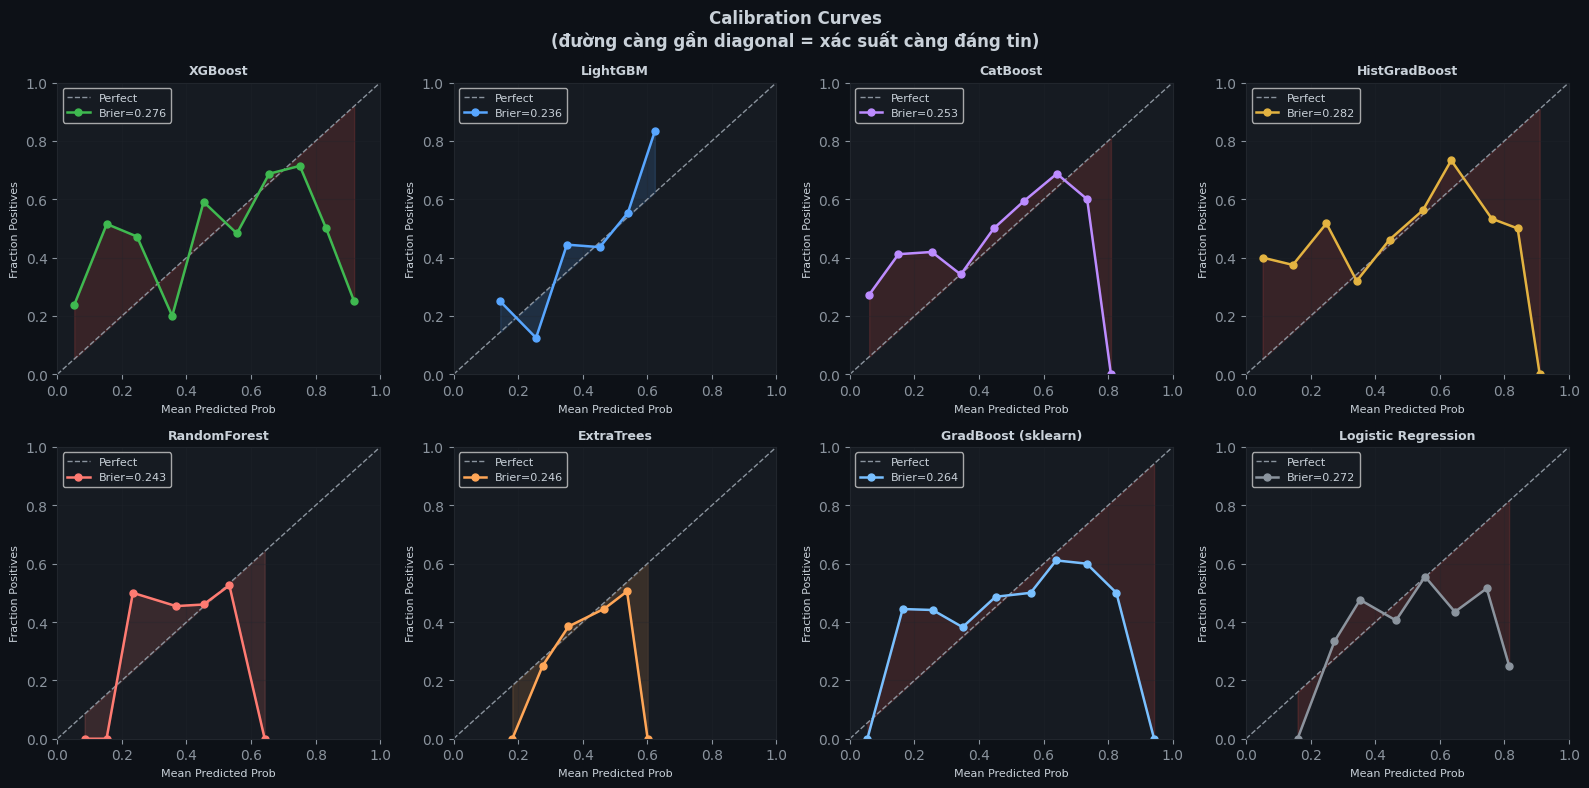

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, (name, r), col in zip(axes, results.items(), COLORS):
    try:
        n_bins = min(10, max(3, len(y_test) // 5))
        frac_pos, mean_pred = calibration_curve(y_test, r['prob_te'], n_bins=n_bins, strategy='uniform')
        ax.plot([0,1],[0,1], '--', color=MUTED, lw=1, label='Perfect')
        ax.plot(mean_pred, frac_pos, 'o-', color=col, lw=1.8, ms=5, label=f'Brier={r["brier"]:.3f}')
        ax.fill_between(mean_pred, frac_pos, mean_pred,
                        alpha=0.15, color=(RED if r['brier'] > 0.25 else col))
    except Exception as e:
        ax.text(0.5, 0.5, f'N/A\n{str(e)[:40]}', ha='center', va='center',
                transform=ax.transAxes, color=MUTED, fontsize=8)
    ax.set_title(name, fontweight='bold', fontsize=9)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Mean Predicted Prob', fontsize=8)
    ax.set_ylabel('Fraction Positives', fontsize=8)

plt.suptitle('Calibration Curves\n(đường càng gần diagonal = xác suất càng đáng tin)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('calibration.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Threshold Analysis — Precision vs Recall trade-off

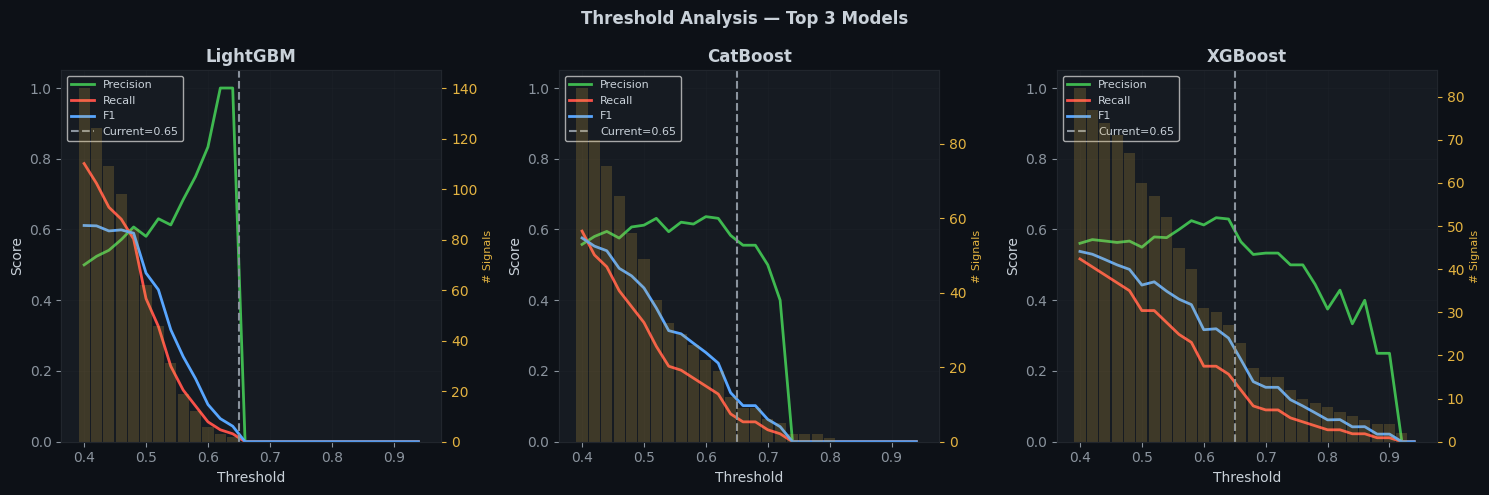

In [9]:
# Chọn top-3 models theo AUC để phân tích threshold
top3 = sorted(results.items(), key=lambda x: x[1]['auc_test'], reverse=True)[:3]
thresholds = np.arange(0.40, 0.95, 0.02)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, r), col in zip(axes, top3, COLORS):
    precs, recs, f1s_th, n_sigs = [], [], [], []
    for th in thresholds:
        pred = (r['prob_te'] >= th).astype(int)
        precs.append(precision_score(y_test, pred, zero_division=0))
        recs.append(recall_score(y_test, pred, zero_division=0))
        f1s_th.append(f1_score(y_test, pred, zero_division=0))
        n_sigs.append(pred.sum())

    ax.plot(thresholds, precs, color=GREEN,  lw=2, label='Precision')
    ax.plot(thresholds, recs,  color=RED,    lw=2, label='Recall')
    ax.plot(thresholds, f1s_th, color=BLUE,  lw=2, label='F1')

    ax2 = ax.twinx()
    ax2.bar(thresholds, n_sigs, width=0.018, alpha=0.2, color=YELLOW, label='# Signals')
    ax2.set_ylabel('# Signals', color=YELLOW, fontsize=8)
    ax2.tick_params(axis='y', colors=YELLOW)

    ax.axvline(THRESHOLD, ls='--', color=MUTED, lw=1.5, label=f'Current={THRESHOLD}')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle('Threshold Analysis — Top 3 Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=130, bbox_inches='tight')
plt.show()

## 9. Feature Importance — Top Models

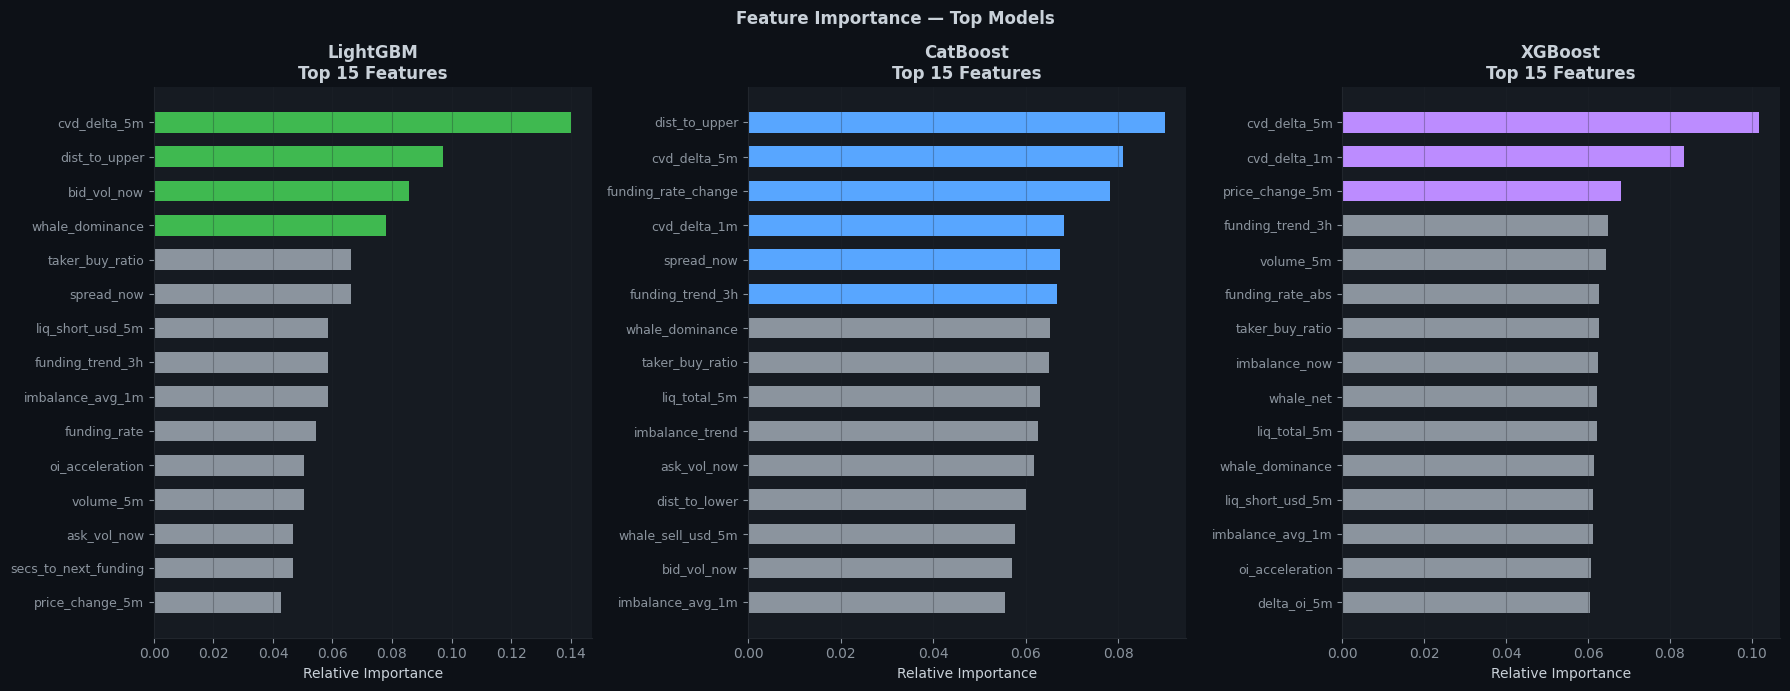

In [10]:
def get_feature_importance(name, model, feature_names):
    """Lấy feature importance từ mọi loại model."""
    try:
        if hasattr(model, 'feature_importances_'):
            fi = model.feature_importances_
        elif hasattr(model, 'named_steps'):  # Pipeline (LogReg)
            clf = model.named_steps['clf']
            fi = np.abs(clf.coef_[0])
        else:
            return None
        return pd.Series(fi, index=feature_names).sort_values(ascending=False)
    except Exception:
        return None

top_n = min(3, len(results))
top_models = sorted(results.items(), key=lambda x: x[1]['auc_test'], reverse=True)[:top_n]

fig, axes = plt.subplots(1, top_n, figsize=(6 * top_n, 7))
if top_n == 1:
    axes = [axes]

TOP_K = 15

for ax, (name, r), col in zip(axes, top_models, COLORS):
    fi = get_feature_importance(name, r['model'], features)
    if fi is None:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        continue

    top = fi.head(TOP_K)
    bar_vals = top.values / top.values.sum()  # normalize
    bar_cols = [col if v >= bar_vals.mean() else MUTED for v in bar_vals]

    ax.barh(range(len(top)), bar_vals[::-1], color=bar_cols[::-1], edgecolor='none', height=0.6)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index[::-1], fontsize=9)
    ax.set_title(f'{name}\nTop {TOP_K} Features', fontweight='bold')
    ax.set_xlabel('Relative Importance')
    ax.grid(True, axis='x', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Importance — Top Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

## 10. SHAP Values — Best Model

Best model: LightGBM (AUC=0.6348)


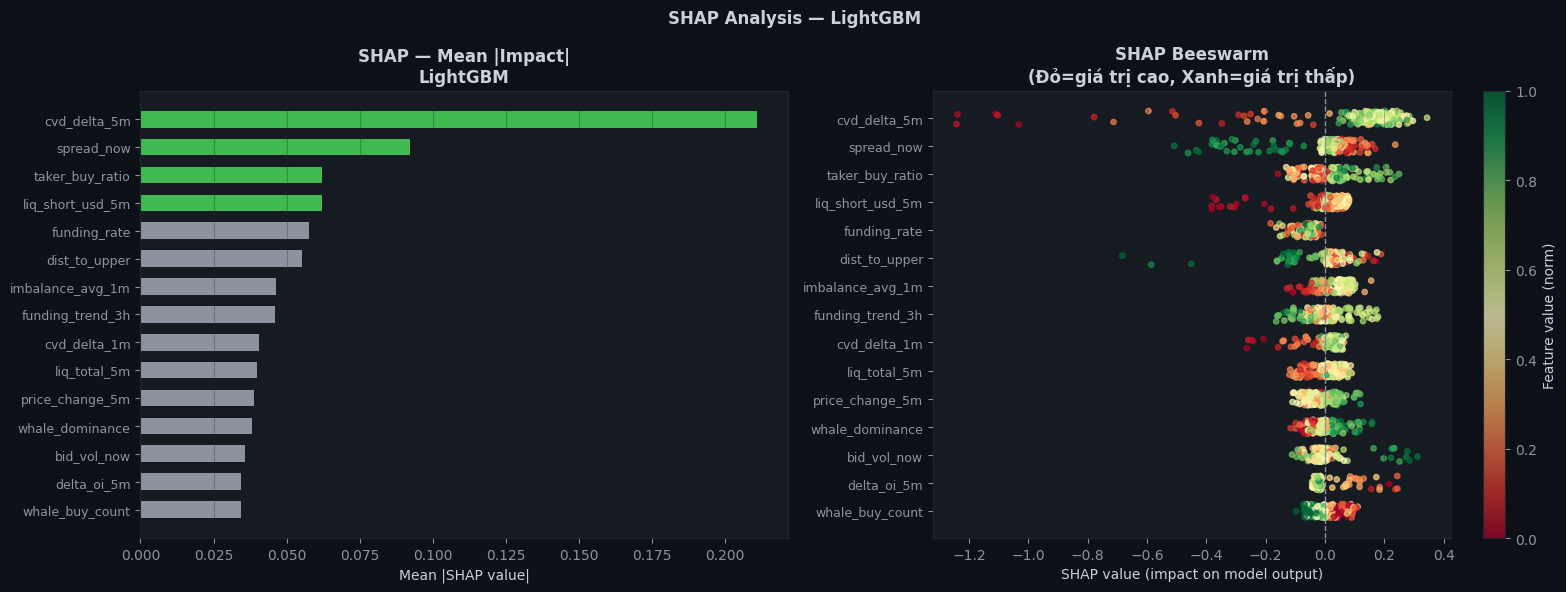

In [11]:
# Lấy best model theo AUC test
best_name, best_r = max(results.items(), key=lambda x: x[1]['auc_test'])
best_model = best_r['model']
print(f'Best model: {best_name} (AUC={best_r["auc_test"]:.4f})')

try:
    if best_name in ('XGBoost', 'LightGBM', 'CatBoost',
                     'HistGradBoost', 'RandomForest', 'ExtraTrees'):
        explainer = shap.TreeExplainer(best_model)
        shap_vals = explainer.shap_values(X_te_imp)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]  # class 1
    else:
        # Fallback: Kernel SHAP (chậm hơn)
        bg = shap.sample(X_tr_imp, 50)
        explainer = shap.KernelExplainer(best_model.predict_proba, bg)
        shap_vals = explainer.shap_values(X_te_imp[:30], nsamples=100)[1]

    shap_df = pd.DataFrame(shap_vals, columns=features)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Mean |SHAP|
    ax = axes[0]
    mean_abs = shap_df.abs().mean().sort_values(ascending=False).head(15)
    bar_c = [GREEN if v >= mean_abs.mean() else MUTED for v in mean_abs.values]
    ax.barh(range(len(mean_abs)), mean_abs.values[::-1], color=bar_c[::-1], height=0.6)
    ax.set_yticks(range(len(mean_abs)))
    ax.set_yticklabels(mean_abs.index[::-1], fontsize=9)
    ax.set_title(f'SHAP — Mean |Impact|\n{best_name}', fontweight='bold')
    ax.set_xlabel('Mean |SHAP value|')
    ax.grid(True, axis='x', alpha=0.3)

    # SHAP summary beeswarm (matplotlib)
    ax = axes[1]
    top15_cols = mean_abs.index.tolist()
    shap_top   = shap_df[top15_cols].values
    X_top      = X_te_imp[:, [features.index(c) for c in top15_cols]]

    for i, col in enumerate(top15_cols[::-1]):
        col_idx  = top15_cols.index(col)
        sv       = shap_top[:, col_idx]
        xv_norm  = (X_top[:, col_idx] - X_top[:, col_idx].min()) / \
                   ((X_top[:, col_idx].max() - X_top[:, col_idx].min()) + 1e-9)
        jitter   = np.random.uniform(-0.25, 0.25, len(sv))
        scatter  = ax.scatter(sv, i + jitter, c=xv_norm, cmap='RdYlGn',
                              s=15, alpha=0.7, vmin=0, vmax=1)

    ax.set_yticks(range(len(top15_cols)))
    ax.set_yticklabels(top15_cols[::-1], fontsize=9)
    ax.axvline(0, color=MUTED, lw=1, ls='--')
    ax.set_xlabel('SHAP value (impact on model output)')
    ax.set_title('SHAP Beeswarm\n(Đỏ=giá trị cao, Xanh=giá trị thấp)', fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Feature value (norm)')

    plt.suptitle(f'SHAP Analysis — {best_name}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_analysis.png', dpi=130, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f'SHAP failed: {e}')
    print('(Cần đủ test samples để SHAP hoạt động tốt)')

## 11. Confusion Matrix — Top Models

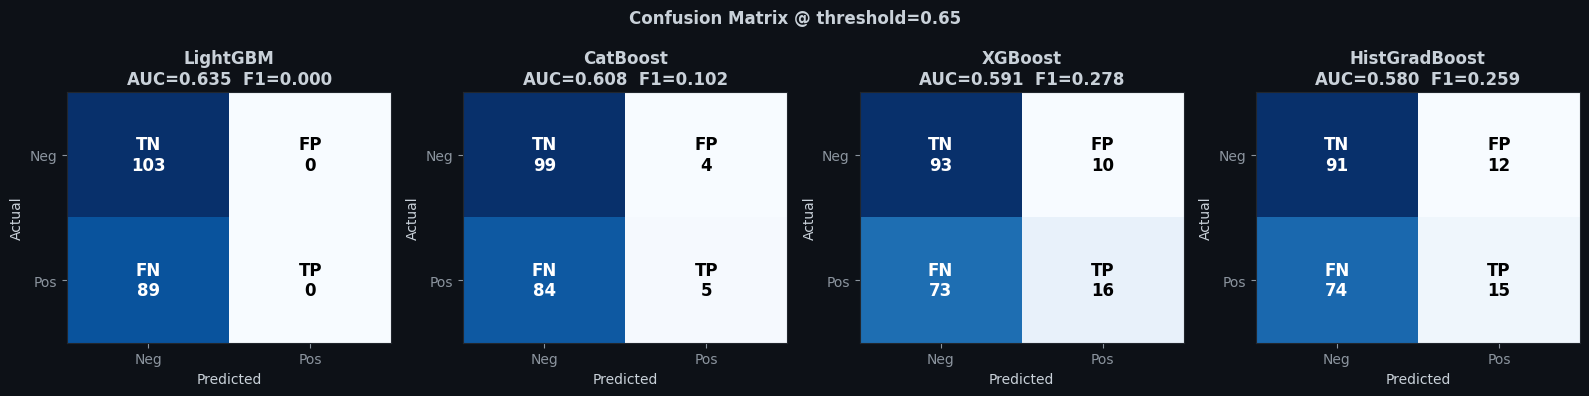

In [12]:
top_n   = min(4, len(results))
top_mdls = sorted(results.items(), key=lambda x: x[1]['auc_test'], reverse=True)[:top_n]

fig, axes = plt.subplots(1, top_n, figsize=(4 * top_n, 4))
if top_n == 1: axes = [axes]

for ax, (name, r) in zip(axes, top_mdls):
    pred = (r['prob_te'] >= THRESHOLD).astype(int)
    cm   = confusion_matrix(y_test, pred)

    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    labels = ['TN', 'FP', 'FN', 'TP']
    vals   = cm.flatten()
    for idx, (label, val) in enumerate(zip(labels, vals)):
        r_i, c_i = divmod(idx, 2)
        ax.text(c_i, r_i, f'{label}\n{val}', ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if val > cm.max()/2 else 'black')

    ax.set_title(f'{name}\nAUC={r["auc_test"]:.3f}  F1={r["f1"]:.3f}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Neg','Pos']); ax.set_yticklabels(['Neg','Pos'])

plt.suptitle(f'Confusion Matrix @ threshold={THRESHOLD}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=130, bbox_inches='tight')
plt.show()

## 12. Kết luận & Khuyến nghị

In [13]:
best  = summary.iloc[0]
worst = summary.iloc[-1]

print('═' * 60)
print('  TỔNG KẾT')
print('═' * 60)
print(f'\n🥇 Best AUC    : {best["Model"]} ({best["AUC Test"]:.4f})')

# Best calibration (lowest Brier)
bc_s = summary['Brier ↓'].dropna(); best_cal = summary.loc[bc_s.idxmin(), 'Model'] if len(bc_s) else 'N/A'; best_bs = bc_s.min() if len(bc_s) else float('nan')
print(f'📏 Best Calib  : {best_cal} (Brier={best_bs:.4f})')

# Fastest
ft_s = summary['Train(s)'].dropna(); fastest = summary.loc[ft_s.idxmin(), 'Model'] if len(ft_s) else 'N/A'; fast_t = ft_s.min() if len(ft_s) else float('nan')
print(f'⚡ Fastest     : {fastest} ({fast_t:.1f}s)')

# Least overfit
og_s = summary['Overfit Gap'].abs().dropna()
if len(og_s) > 0:
    low_of = summary.loc[og_s.idxmin(), 'Model']; low_gap = og_s.min()
    print(f'🎯 Least Overfit: {low_of} (gap={low_gap:+.4f})')

print('\n── Chi tiết top 3 ──────────────────────────────────')
cols_show = ['Model','AUC Test','PR-AUC','Overfit Gap',f'Precision@{THRESHOLD}',f'F1@{THRESHOLD}','Brier ↓','Train(s)']
print(summary[cols_show].head(3).to_string(index=False))

print('\n── Ghi chú ─────────────────────────────────────────')
print('  AUC > 0.70  : model có giá trị dự đoán tốt')
print('  Overfit gap > 0.10 : nguy cơ overfit (cần regularize mạnh hơn)')
print('  Brier < 0.20 : xác suất được calibrate tốt')
print('  Với data ít (<500 rows), nên ưu tiên model đơn giản hơn (LR, RF)')
print('  Với data >5000 rows, XGB/LGB/CatBoost thường dẫn đầu')

print('\n── Khuyến nghị cho production ──────────────────────')
print('  1. Thu thập 2,000+ labeled rows rồi retrain')
print('  2. Chạy cross-validation (TimeSeriesSplit) để đánh giá ổn định hơn')
print('  3. Calibrate xác suất bằng IsotonicRegression nếu Brier > 0.22')
print('  4. Monitor AUC drift hàng tuần khi deploy thật')
print('═' * 60)

════════════════════════════════════════════════════════════
  TỔNG KẾT
════════════════════════════════════════════════════════════

🥇 Best AUC    : LightGBM (0.6348)
📏 Best Calib  : LightGBM (Brier=0.2357)
⚡ Fastest     : Logistic Regression (0.0s)
🎯 Least Overfit: Logistic Regression (gap=+0.1629)

── Chi tiết top 3 ──────────────────────────────────
   Model  AUC Test  PR-AUC  Overfit Gap  Precision@0.65  F1@0.65  Brier ↓  Train(s)
LightGBM    0.6348  0.6039       0.2779          0.0000   0.0000   0.2357      1.05
CatBoost    0.6078  0.5562       0.3922          0.5556   0.1020   0.2534      0.96
 XGBoost    0.5909  0.5341       0.3933          0.6154   0.2783   0.2760     13.29

── Ghi chú ─────────────────────────────────────────
  AUC > 0.70  : model có giá trị dự đoán tốt
  Overfit gap > 0.10 : nguy cơ overfit (cần regularize mạnh hơn)
  Brier < 0.20 : xác suất được calibrate tốt
  Với data ít (<500 rows), nên ưu tiên model đơn giản hơn (LR, RF)
  Với data >5000 rows, XGB/LGB/C

## 13. Cross-Validation với TimeSeriesSplit (bonus)

TimeSeriesSplit (5 folds) — AUC per fold:

  Logistic Regression       folds=[0.505 0.511 0.609 0.633 0.529]  mean=0.5575 ± 0.0530


  ExtraTrees                folds=[0.516 0.49  0.59  0.658 0.596]  mean=0.5700 ± 0.0604


  RandomForest              folds=[0.542 0.501 0.591 0.669 0.552]  mean=0.5710 ± 0.0569


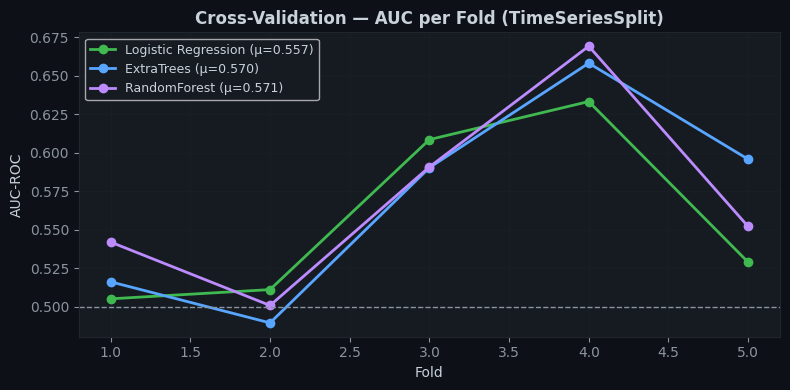

In [14]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Chỉ chạy 3 models nhanh nhất để không mất quá nhiều thời gian
fast_models = sorted(results.items(), key=lambda x: x[1]['train_sec'])[:3]
tscv = TimeSeriesSplit(n_splits=5)

X_all = np.vstack([X_tr_imp, X_te_imp])
y_all = np.concatenate([y_train, y_test])

cv_results = {}
print('TimeSeriesSplit (5 folds) — AUC per fold:\n')

for name, r in fast_models:
    model = r['model']
    try:
        # Với Pipeline (LogReg), clone trực tiếp
        from sklearn.base import clone
        m_clone = clone(model)
        scores = cross_val_score(m_clone, X_all, y_all, cv=tscv,
                                 scoring='roc_auc', n_jobs=1)
        cv_results[name] = scores
        print(f'  {name:<25} folds={np.round(scores,3)}  mean={scores.mean():.4f} ± {scores.std():.4f}')
    except Exception as e:
        print(f'  {name:<25} SKIP ({e})')

# Plot
if cv_results:
    fig, ax = plt.subplots(figsize=(8, 4))
    for (name, scores), col in zip(cv_results.items(), COLORS):
        ax.plot(range(1, len(scores)+1), scores, 'o-', color=col, lw=2, ms=6, label=f'{name} (μ={scores.mean():.3f})')
    ax.axhline(0.5, ls='--', color=MUTED, lw=1)
    ax.set_xlabel('Fold'); ax.set_ylabel('AUC-ROC')
    ax.set_title('Cross-Validation — AUC per Fold (TimeSeriesSplit)', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('cv_results.png', dpi=130, bbox_inches='tight')
    plt.show()